**อย่าลืมเปลี่ยนเป็น รันบน GPU นะคะ**

# 🐶 YOLOv11 & Roboflow: Dog Breed Detection Lab
**โจทย์:** การตรวจจับสายพันธุ์สุนัข 3 สายพันธุ์ (ชิสุ: `shih_tzu`, เฟรนช์บลูด็อก: `french_bulldog`, โกลเด้นรีทรีฟเวอร์: `golden_retriever`)

### 🎯 วัตถุประสงค์การเรียนรู้
1. เรียนรู้การตั้งค่าสภาพแวดล้อมและการเตรียมข้อมูล `data.yaml` ร่วมกับ Roboflow
2. ฝึกเทรนโมเดลเริ่มต้น (Baseline Model Training)
3. ประเมินและอ่านค่าวัดผลประสิทธิภาพ (mAP, Precision, Recall, Confusion Matrix) จากไฟล์ `best.pt`
4. ปรับจูน Hyperparameters (Fine-Tuning) เพื่อเพิ่มประสิทธิภาพโมเดล
5. เปรียบเทียบผลลัพธ์ระหว่าง Baseline และ Fine-Tuned Model
6. นำโมเดลที่สมบูรณ์ที่สุดไปทดสอบทำนายผลภาพจริง (Inference)

**goto Document YOLO11** : https://docs.ultralytics.com/models/yolo11/#overview  and goto GitHub ของ YOLO11 https://github.com/ultralytics/ultralytics

**Install**
Pip install the Ultralytics package including all requirements in a Python>=3.8 environment with PyTorch>=1.8.




---
## Step 1: ติดตั้งและตรวจสอบสภาพแวดล้อมระบบ (Setup & Installation)

In [16]:
# ตรวจสอบการใช้งาน GPU บน Colab
!nvidia-smi

# ติดตั้ง Ultralytics (YOLOv8) และไลบรารีที่จำเป็น
!pip install -q ultralytics roboflow opencv-python matplotlib

Tue Sep 22 07:57:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             35W /   70W |     973MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Step 2: เตรียม Dataset และสร้างไฟล์ Configuration (`data.yaml`)

In [ ]:
import pandas as pd
path = '/content/drive/MyDrive/Colab Notebooks/ML Datascience/Project/Bottle.v3i.yolov11'

---
## Step 3: ฝึกโมเดลเริ่มต้น (Baseline Model Training)

In [ ]:
from ultralytics import YOLO

# 1. โหลด Pre-trained Model ขนาดเล็ก (YOLOv11 Nano) เป็น Baseline
model = YOLO("yolo11n.pt")

# 2. ฝึกโมเดลรอบแรกด้วยค่า Default
train_results = model.train(
    data= "/content/drive/MyDrive/Colab Notebooks/ML Datascience/Project/Bottle.v3i.yolov11/data.yaml",  # path to dataset YAML
    epochs=100,  # number of training epochs
    imgsz=640,  # training image size
    device=0,  # use GPU; '0' specifies the first GPU   or device=0,1,2,3 or device=cpu
    workers=2, # use multiple workers for data loading
    seed=42,
    batch=16,
    project='Water Bottle',
    name='tuned_yolov11n',
)




Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.158 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/ML Datascience/Project/Bottle.v3i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=Fa

---
## Step 4: ประเมินผลและแสดง Performance Metrics จาก `best.pt`

In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

# 1. โหลดน้ำหนักที่ดีที่สุด (best.pt) จากการเทรน Baseline
best_baseline_path = '/content/runs/detect/Water Bottle/tuned_yolov11n/weights/best.pt'
model_eval = YOLO(best_baseline_path)
print(model_eval)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

**ทดลองปรับค่า conf ตามผลของการตรวจจับที่ได้**

In [ ]:

# 2. ประเมินผลบน Validation Set
#metrics = model_eval.val(data='/content/drive/MyDrive/Colab Notebooks/yolov11/dataset/data.yaml',conf = 0.4)
metrics = model_eval.val(data='/content/drive/MyDrive/Colab Notebooks/ML Datascience/Project/Bottle.v3i.yolov11/data.yaml',conf = 0.6)

Ultralytics 8.4.158 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.1 ms, read: 37.3±15.3 MB/s, size: 37.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Colab Notebooks/ML Datascience/Project/Bottle.v3i.yolov11/valid/labels.cache... 92 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 92/92 27.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.0it/s 3.0s
                   all         92        228      0.965      0.894       0.89      0.692
            bad_bottle         39         42      0.976      0.976      0.973       0.83
           good_bottle         53         68      0.967      0.853      0.849       0.72
            

In [ ]:
#แสดงระยะเวลาในการประมวลผล ก่อน ประมวลผล และหลัง
print(metrics.speed)

{'preprocess': 5.981181500018189, 'inference': 6.068121423911931, 'loss': 0.0017237825886695646, 'postprocess': 5.436357206532272}


In [ ]:
for p in model_eval.parameters():
    print(p)

Streaming output truncated to the last 5000 lines.
         [[ 0.0097, -0.0238,  0.0028],
          [-0.0147, -0.0102,  0.0075],
          [ 0.0058,  0.0061,  0.0117]],

         [[ 0.0195,  0.0219, -0.0210],
          [ 0.0220,  0.0099, -0.0224],
          [ 0.0038, -0.0247, -0.0205]],

         [[-0.0200, -0.0020,  0.0241],
          [-0.0058,  0.0120,  0.0307],
          [ 0.0118,  0.0023, -0.0019]]],


        [[[-0.0212, -0.0034, -0.0159],
          [-0.0483, -0.0488, -0.0134],
          [-0.0113, -0.0271, -0.0112]],

         [[ 0.0347, -0.0086, -0.0068],
          [-0.0129, -0.0169,  0.0198],
          [-0.0251, -0.0171,  0.0110]],

         [[-0.0177, -0.0129,  0.0268],
          [ 0.0113, -0.0006,  0.0013],
          [ 0.0232,  0.0052,  0.0117]],

         ...,

         [[ 0.0328, -0.0533,  0.1316],
          [ 0.0434, -0.0252,  0.0256],
          [ 0.0540,  0.0297, -0.0714]],

         [[ 0.0597, -0.0081,  0.0118],
          [ 0.0341, -0.0124,  0.0039],
          [ 0.0159,  

In [ ]:
# 3. แสดงค่าตัววัดประสิทธิภาพสำคัญ

import torch

# Calculate FPS from the metrics object
# metrics.speed is a dictionary containing 'preprocess', 'inference', 'postprocess' times in ms
total_inference_time_ms = metrics.speed['preprocess'] + metrics.speed['inference'] + metrics.speed['postprocess']
fps = 1000 / total_inference_time_ms

# Get model size (total number of parameters)
# The model_eval object contains the loaded YOLO model
# We sum the number of elements in each parameter tensor
model_parameters = sum(p.numel() for p in model_eval.parameters())


print("\n================ Baseline Model Performance ================")
print(f"mAP@0.5                 : {metrics.box.map50:.4f}")
print(f"mAP@0.50:0.95           : {metrics.box.map:.4f}")
print(f"Precision               : {metrics.box.mp:.4f}")
print(f"Recall                  : {metrics.box.mr:.4f}")
print(f"Average FPS             : {fps:.2f}")
print(f"Model Size (Parameters) : {model_parameters:,}")
print("===========================================================\n")



================ Baseline Model Performance ================
mAP@0.5                 : 0.8898
mAP@0.50:0.95           : 0.6919
Precision               : 0.9646
Recall                  : 0.8939
Average FPS             : 57.19
Model Size (Parameters) : 2,590,620



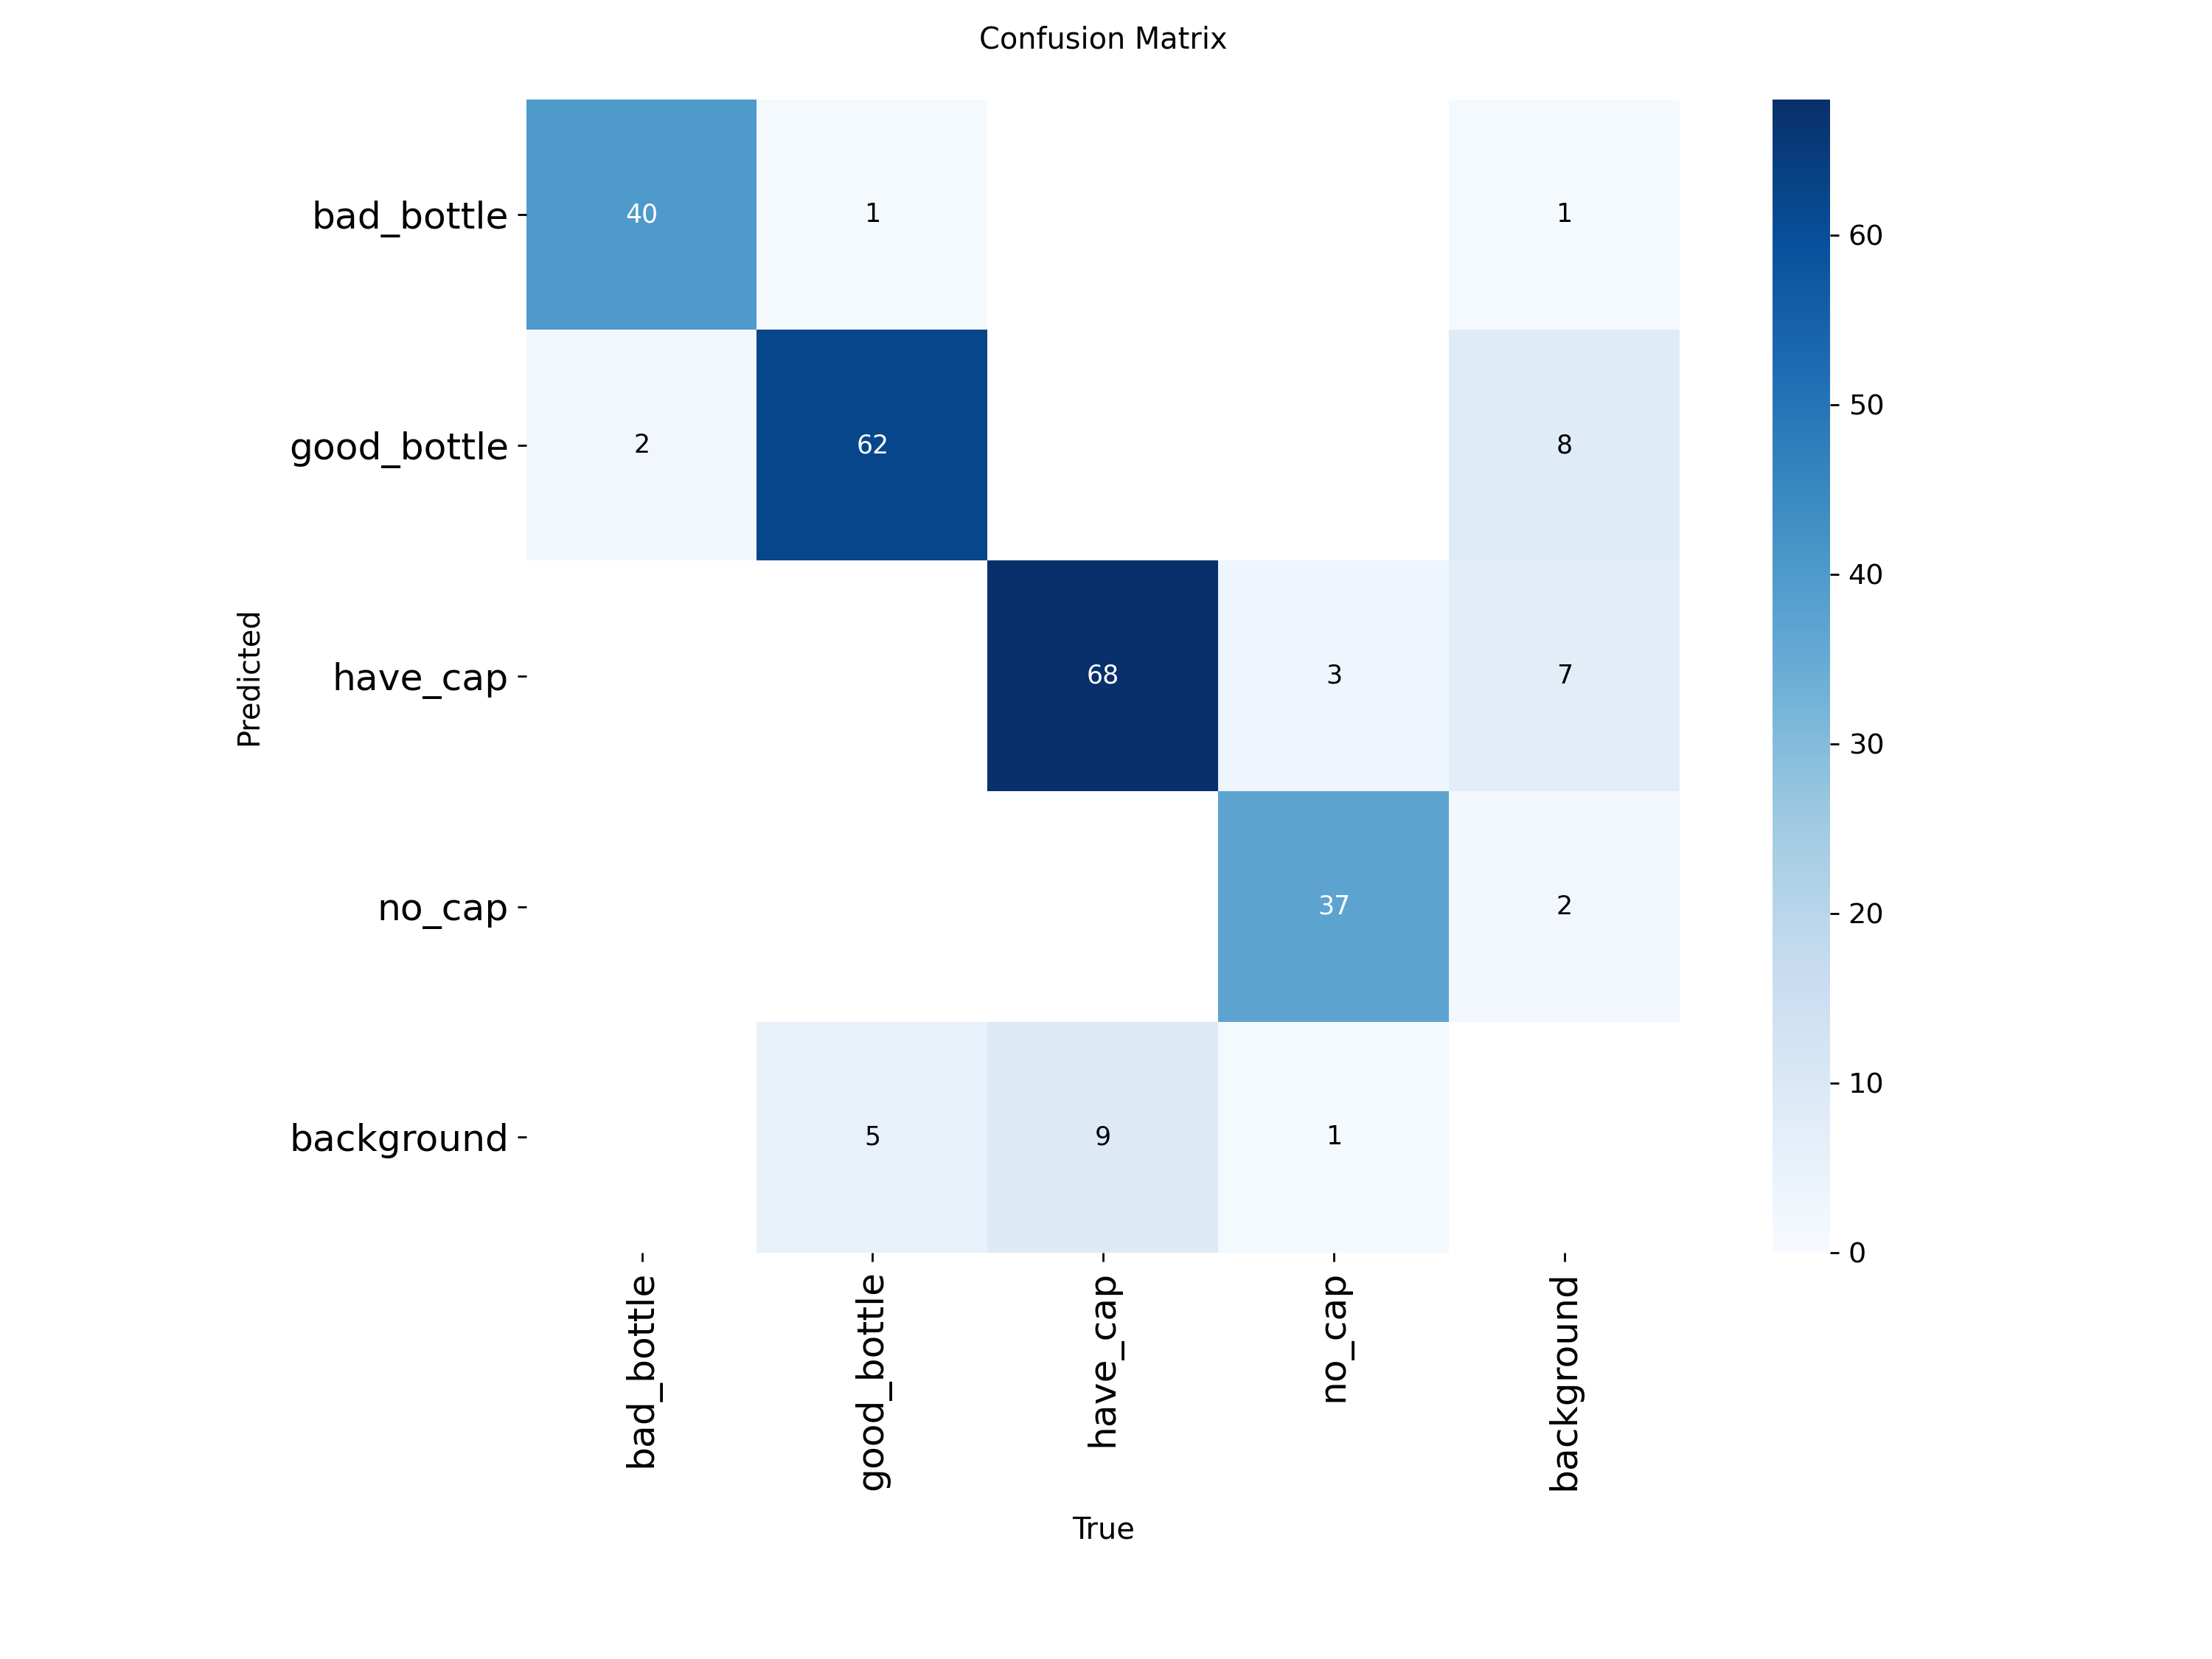

In [ ]:
from IPython.display import Image as IPyImage
#แสดงภาพ confusion matrix
IPyImage(filename=f'/content/runs/detect/Water Bottle/tuned_yolov11n/confusion_matrix.png', width=600)


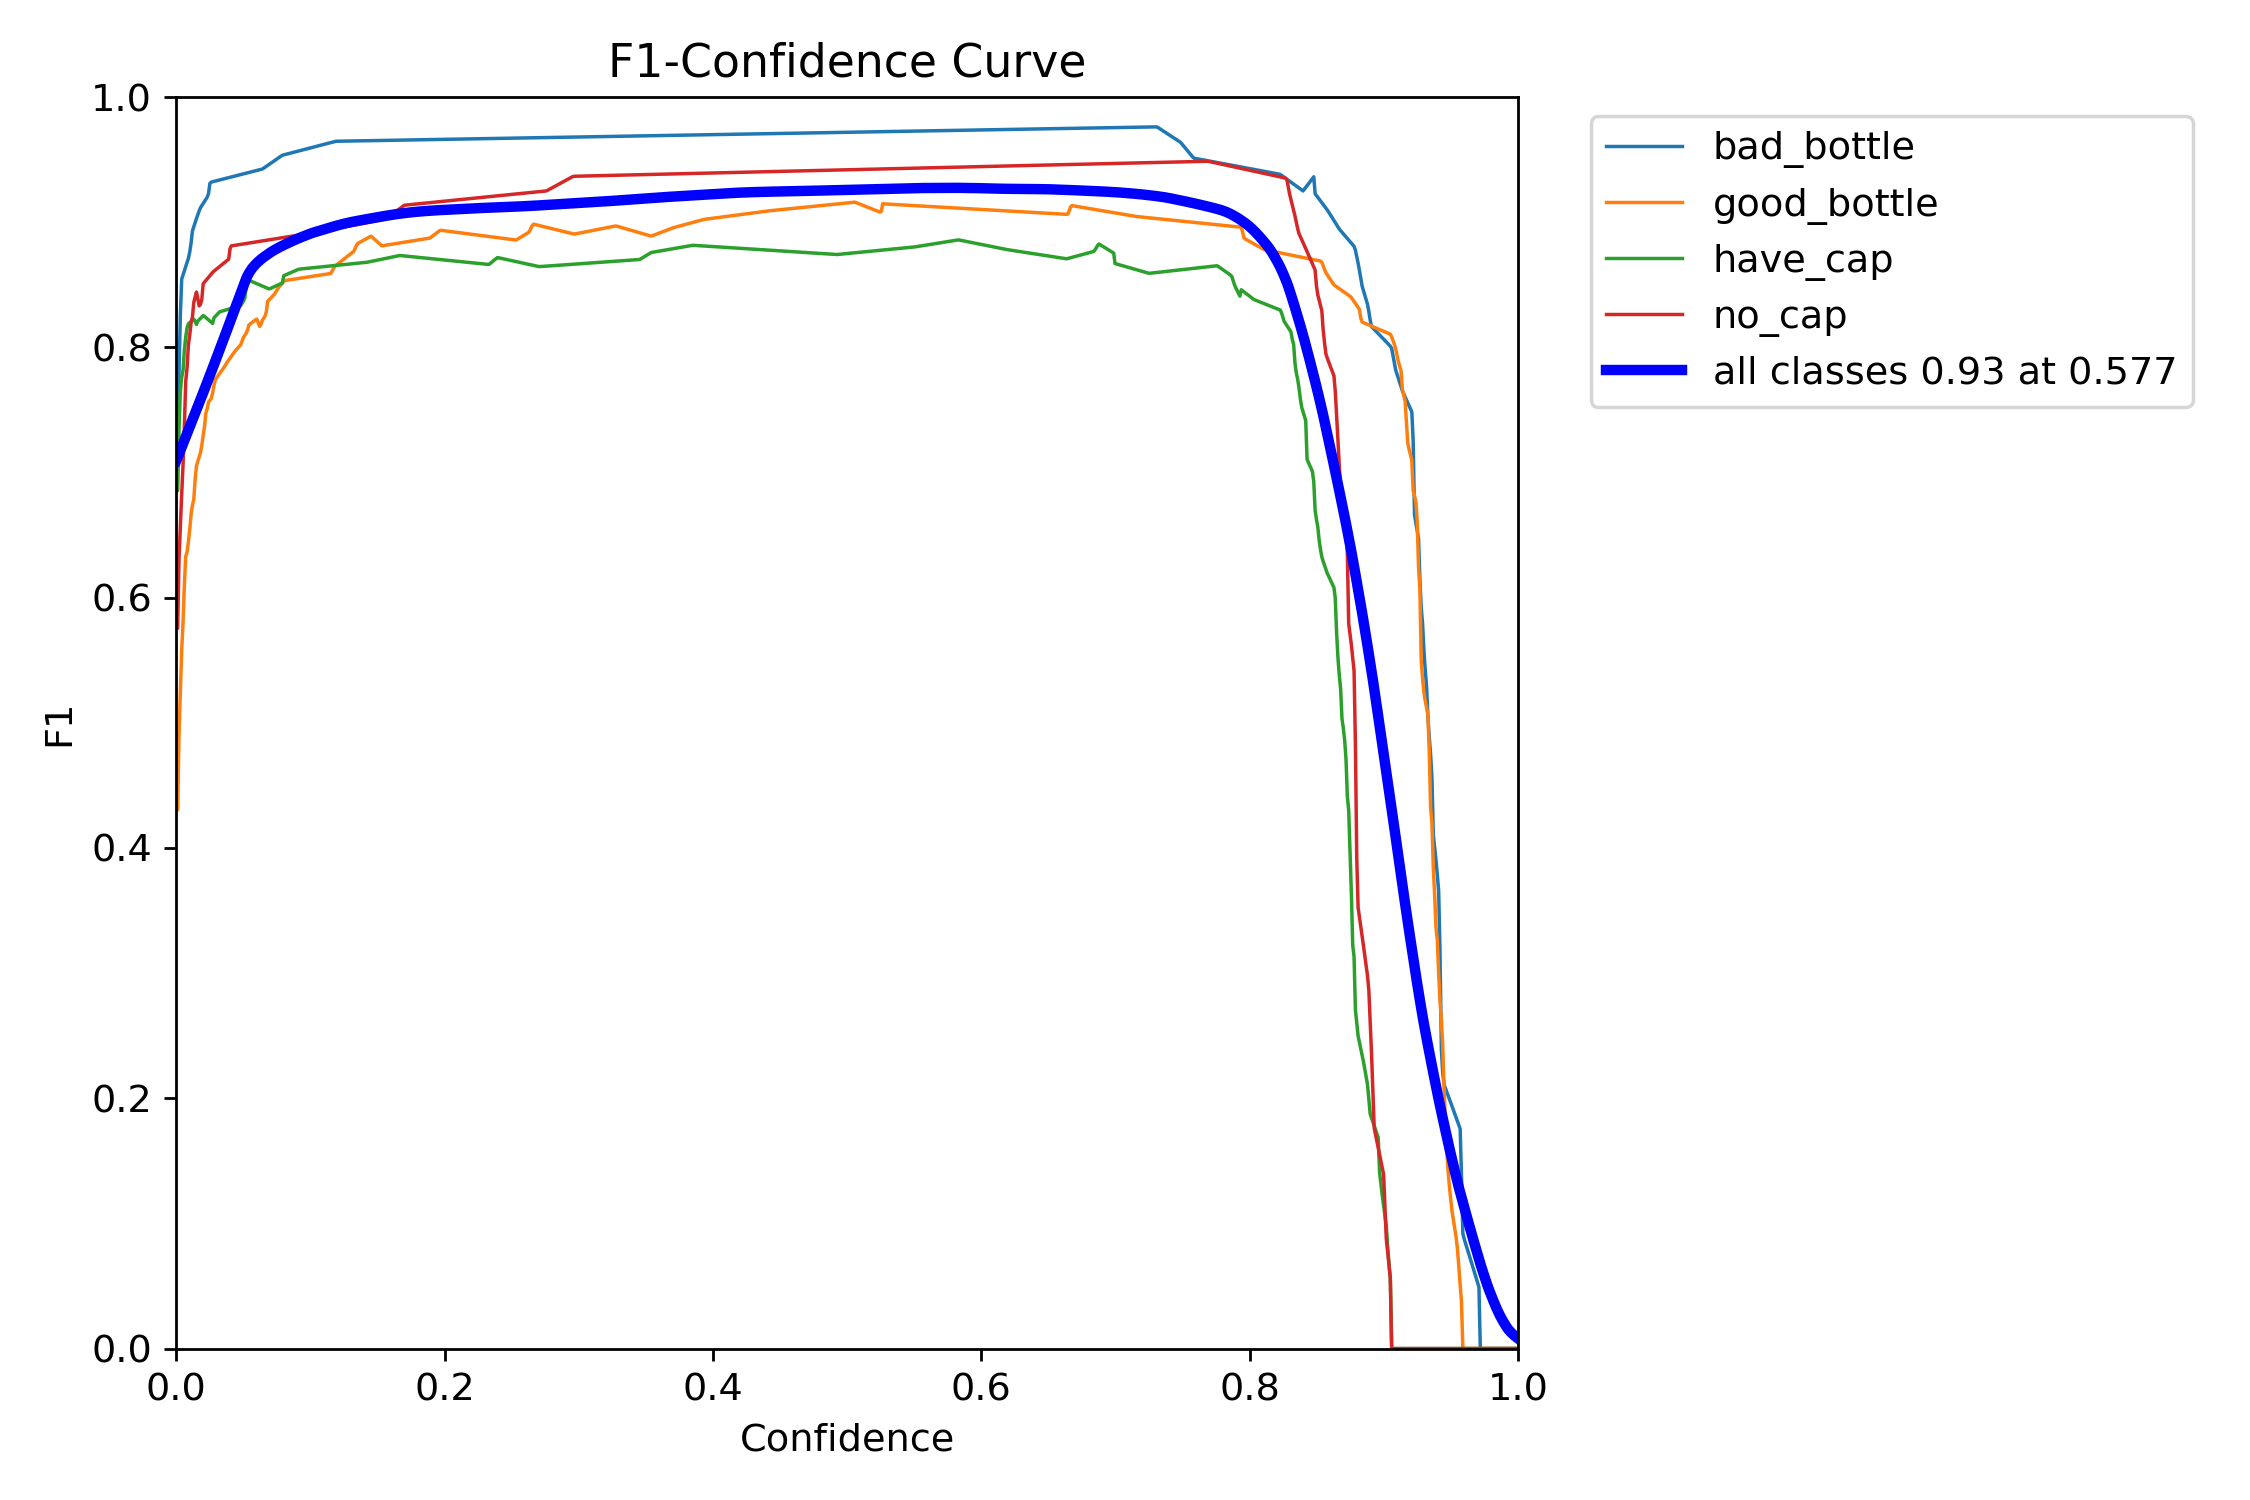

In [ ]:
#แสดงภาพ F1-Score Curve
IPyImage(filename=f'/content/runs/detect/Water Bottle/tuned_yolov11n/BoxF1_curve.png', width=600)

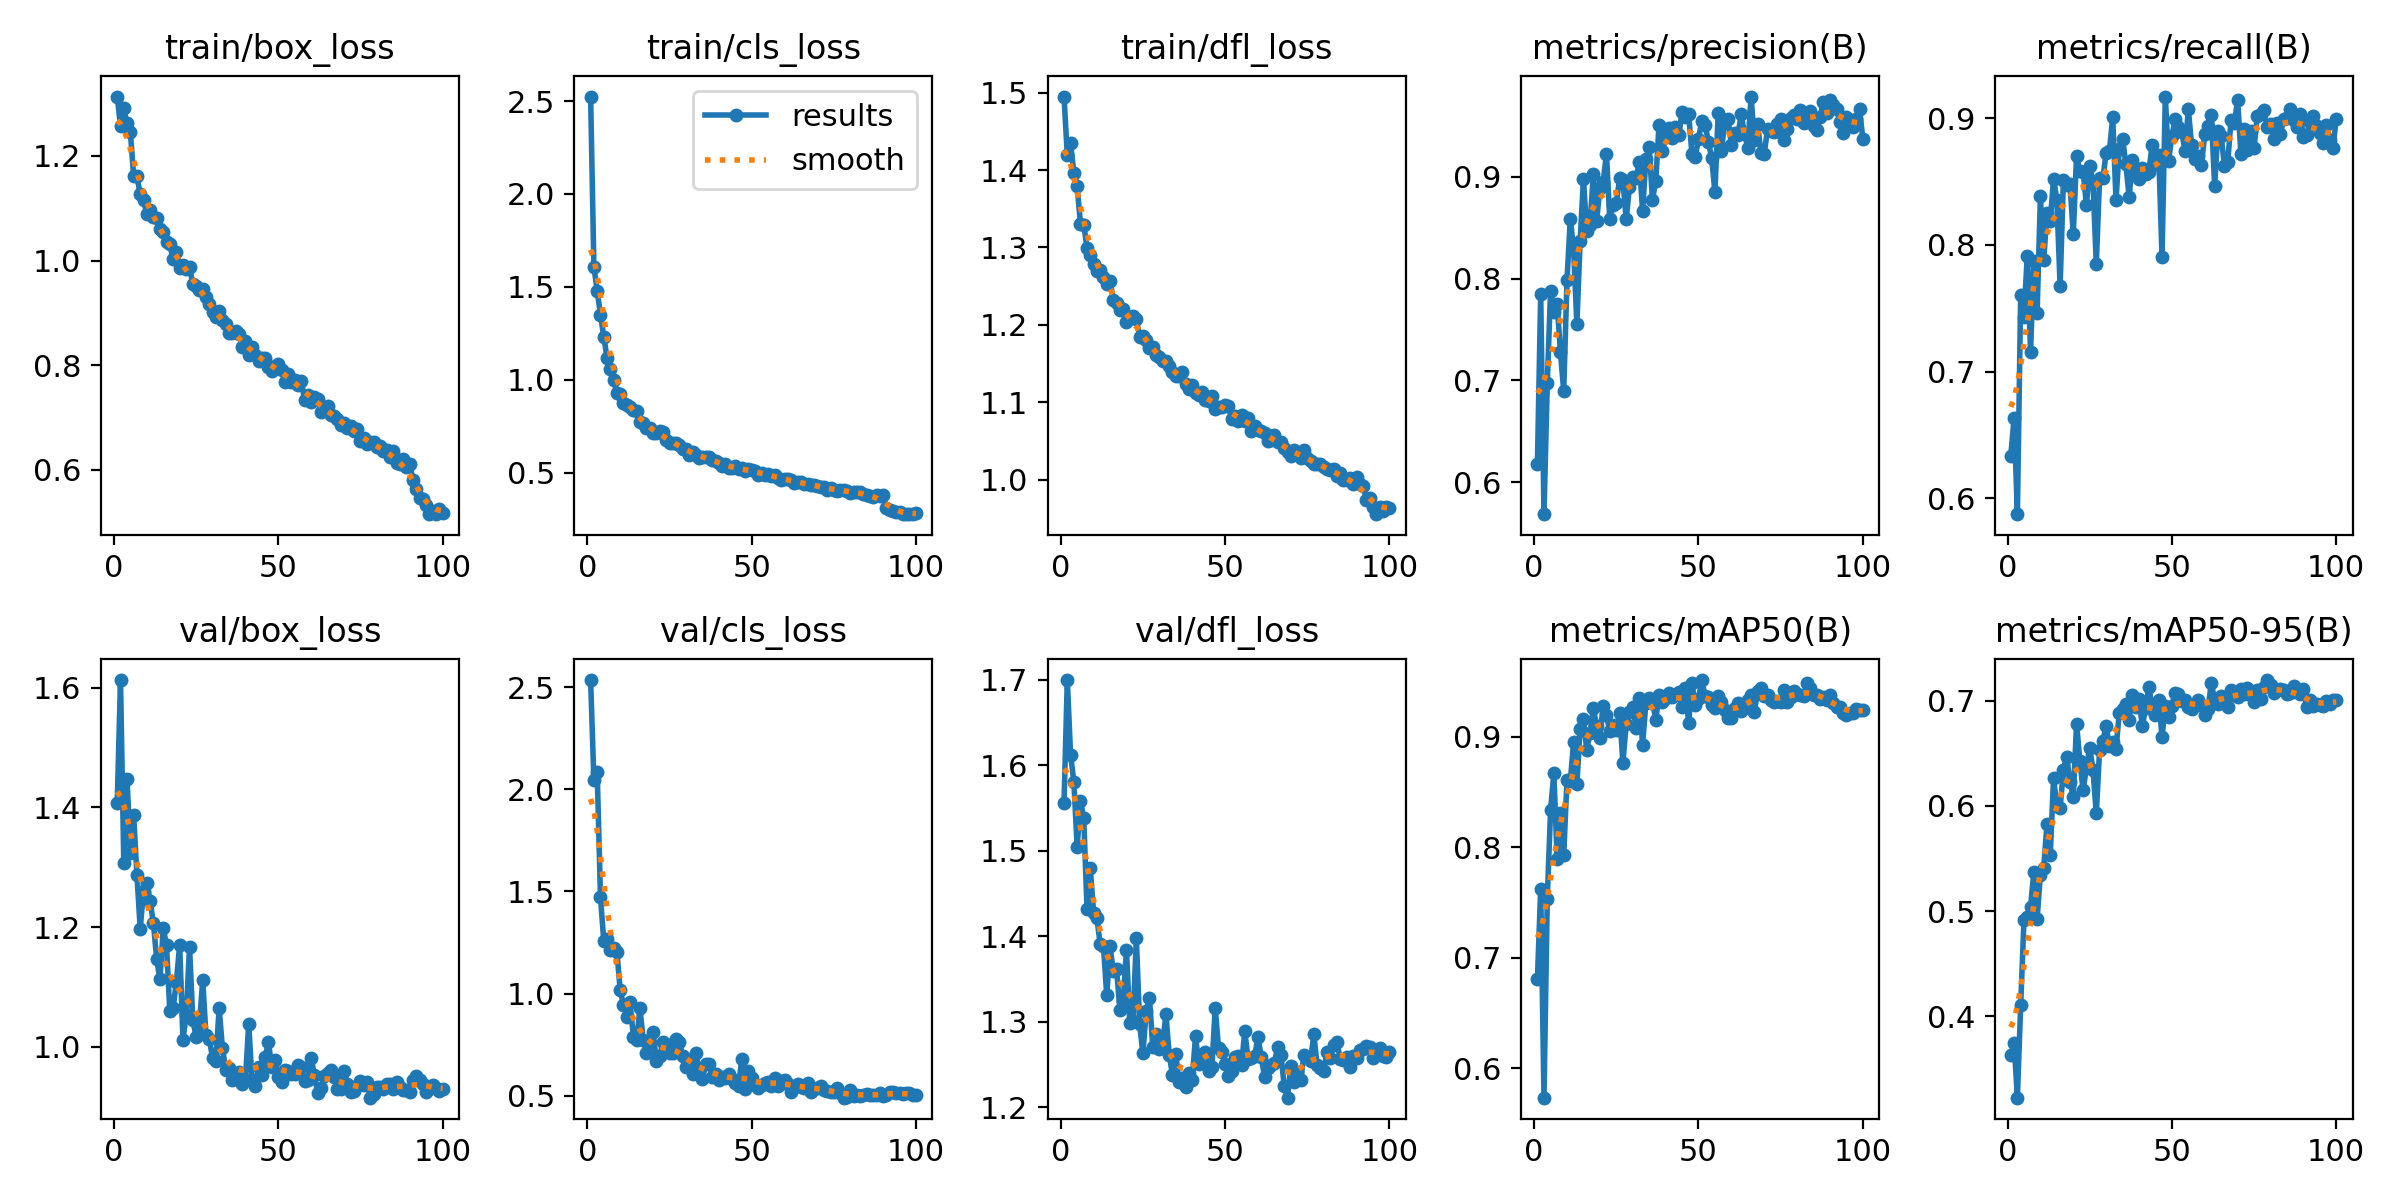

In [ ]:
#แสดงกราฟประสิทธิภาพทั้งหมด

IPyImage(filename=f'/content/runs/detect/Water Bottle/tuned_yolov11n/results.png', width=600)

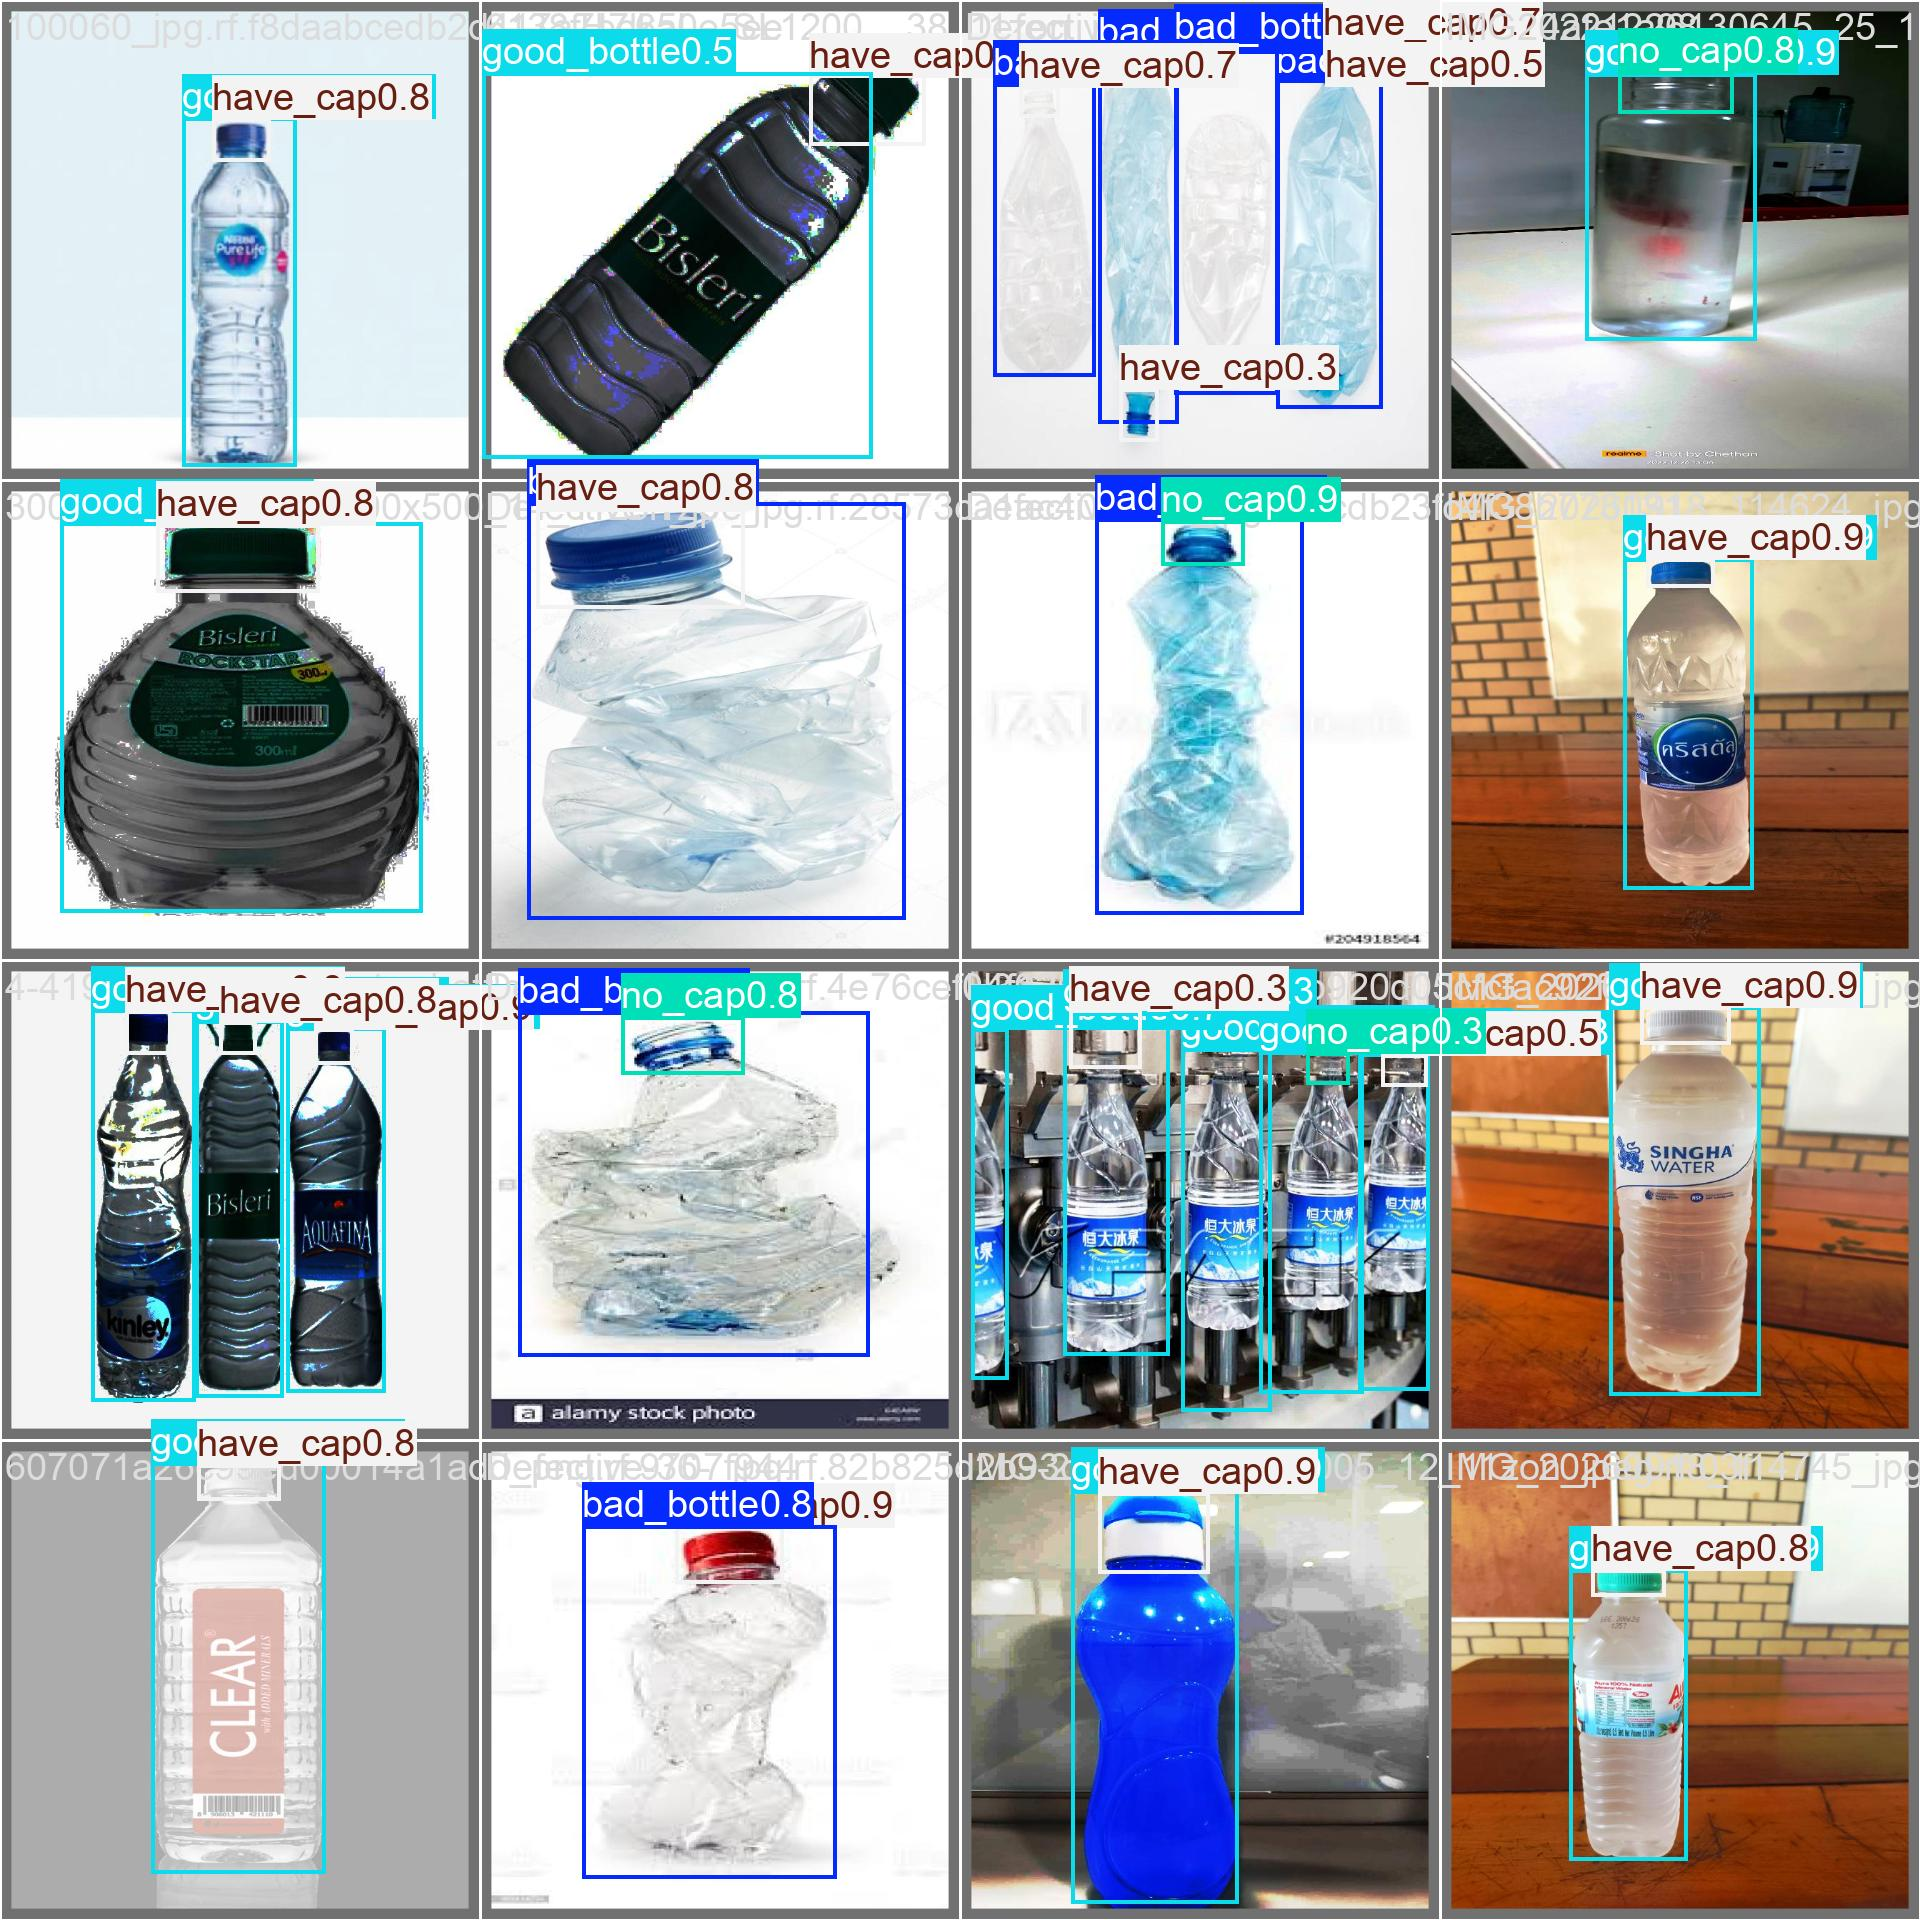

In [ ]:
#แสดงผลลัพธ์กับชุด Validate

IPyImage(filename=f'/content/runs/detect/Water Bottle/tuned_yolov11n/val_batch0_pred.jpg', width=600)

---
## Step 5: การปรับแต่งพารามิเตอร์ขั้นสูง (Hyperparameter Tuning & Fine-Tuning)

หลังดูผล baseline แล้ว (เช่น loss ยังลดไม่สุด หรือ mAP โตช้า) ให้ลองปรับพารามิเตอร์เหล่านี้:

| พารามิเตอร์ | ผลของการปรับ |
|---|---|
| `epochs` ↑ | โมเดลเรียนรู้นานขึ้น แต่เสี่ยง overfit ถ้ามากเกินไป |
| `lr0` (learning rate) | ค่าสูงเรียนเร็วแต่ไม่นิ่ง, ค่าต่ำนิ่งกว่าแต่ช้า |
| `batch` ↑ | เทรนเสถียรขึ้นถ้า GPU รองรับ (ใช้ VRAM มากขึ้น) |
| `optimizer` | `AdamW` มักลู่เข้าเร็วกว่า `SGD` ในดาต้าเซตขนาดเล็ก |
| `mosaic`, `mixup` | Augmentation ที่ช่วยให้โมเดล generalize ดีขึ้น ลด overfitting |
| `patience` ↑ | ให้โอกาสโมเดลพัฒนานานขึ้นก่อนหยุดอัตโนมัติ |

ลองเทรนรอบที่ 2 ด้วยค่าที่ปรับแล้ว:

In [ ]:
# กลยุทธ์ในการปรับแต่ง (Optimization Strategies):
# 1. เปลี่ยนใช้ yolov11s.pt (Small Model) เพื่อเพิ่ม Capacity ในการเรียนรู้ลักษณะขนและใบหน้าสุนัข
# 2. เปลี่ยน Optimizer เป็น AdamW ช่วยเพิ่มความเสถียรในการปรับ Weight
# 3. เพิ่ม Data Augmentation (Mosaic, Mixup, Random Rotation) ป้องกัน Overfitting

model_tuned = YOLO('yolo11s.pt')

results_tuned = model_tuned.train(
    data='/content/drive/MyDrive/Colab Notebooks/yolov11/dataset/data.yaml',
    epochs=70,
    imgsz=640,
    batch=16,
    optimizer='AdamW',       # เปลี่ยนเป็น AdamW Optimizer
    lr0=0.001,               # Initial Learning Rate
    lrf=0.01,                # Final Learning Rate Ratio
    momentum=0.937,
    weight_decay=0.0005,
    mosaic=1.0,              # ผสาน 4 ภาพ เพิ่มความสามารถจับสุนัขมุมแปลกๆ
    mixup=0.2,               # ซ้อนทับภาพ ช่วยกรณีสุนัขยืนบังกัน
    degrees=10.0,            # สุ่มหมุนภาพ +-15 องศา
    fliplr=0.5,              # สุ่มพลิกภาพซ้าย-ขวา
    patience=15,             # Early stopping หาก Loss ไม่ลดใน 15 Epochs
    project='dog_breed_project',
    name='tuned_yolov11s',
    seed=42
)

Ultralytics 8.4.135 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/yolov11/dataset/data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

---
## Step 6: เปรียบเทียบผลลัพธ์ระหว่าง Baseline และ Fine-Tuned Model

In [ ]:
# 1. ประเมินผลโมเดล Fine-Tuned จาก best.pt ตัวใหม่
best_tuned_path = '/content/runs/detect/dog_breed_project/tuned_yolov11s/weights/best.pt'
model_tuned_eval = YOLO(best_tuned_path)
metrics_tuned = model_tuned_eval.val(data='/content/drive/MyDrive/Colab Notebooks/yolov11/dataset/data.yaml')

# 2. คำนวณค่า  FPS และหา model parameters สำหรับ tuned model
total_inference_time_ms_tuned = metrics_tuned.speed['preprocess'] + metrics_tuned.speed['inference'] + metrics_tuned.speed['postprocess']
fps_tuned = 1000 / total_inference_time_ms_tuned
model_parameters_tuned = sum(p.numel() for p in model_tuned_eval.parameters())

# 3. คำนวณผลต่าง
map50_diff = metrics_tuned.box.map50 - metrics.box.map50
map5095_diff = metrics_tuned.box.map - metrics.box.map
p_diff = metrics_tuned.box.mp - metrics.box.mp
r_diff = metrics_tuned.box.mr - metrics.box.mr
fps_diff = fps_tuned - fps
model_parameters_diff = model_parameters_tuned - model_parameters


In [ ]:

# 4.และแสดงตารางเปรียบเทียบ
print("\n" + "="*72)
print(f"{'Metric':<18} | {'Baseline (v11n)':<15} | {'Tuned (v11s)':<15} | {'Improvement':<12}")
print("-" * 72)
print(f"{'mAP@0.5':<18} | {metrics.box.map50:<15.4f} | {metrics_tuned.box.map50:<15.4f} | {map50_diff:+12.4f}")
print(f"{'mAP@0.50:0.95':<18} | {metrics.box.map:<15.4f} | {metrics_tuned.box.map:<15.4f} | {map5095_diff:+12.4f}")
print(f"{'Precision':<18} | {metrics.box.mp:<15.4f} | {metrics_tuned.box.mp:<15.4f} | {p_diff:+12.4f}")
print(f"{'Recall':<18} | {metrics.box.mr:<15.4f} | {metrics_tuned.box.mr:<15.4f} | {r_diff:+12.4f}")
print(f"{'FPS':<18} | {fps:<15.2f} | {fps_tuned:<15.2f} | {fps_diff:+12.2f}")
print(f"{'Model Size(Params)':<18} | {model_parameters:<15,} | {model_parameters_tuned:<15,} | {model_parameters_diff:+12,}")
print("="*72 + "\n")


Metric             | Baseline (v11n) | Tuned (v11s)    | Improvement 
------------------------------------------------------------------------
mAP@0.5            | 0.9950          | 0.9086          |      -0.0864
mAP@0.50:0.95      | 0.6604          | 0.5364          |      -0.1240
Precision          | 0.8393          | 0.8650          |      +0.0257
Recall             | 0.9846          | 0.7721          |      -0.2125
FPS                | 124.72          | 68.83           |       -55.89
Model Size(Params) | 2,582,737       | 9,413,961       |   +6,831,224



---
## Step 7: ทดสอบทำนายผลภาพจริงด้วย `best.pt` (Inference) Unseen Data

# ภาพที่ 1 testdog.png


image 1/1 /content/testdog.png: 608x640 2 shih_tzus, 2 french_bulldogs, 11.5ms
Speed: 3.0ms preprocess, 11.5ms inference, 1.7ms postprocess per image at shape (1, 3, 608, 640)


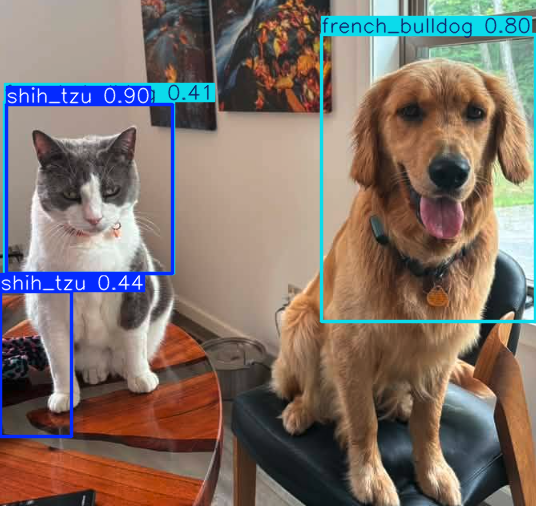

In [ ]:
from ultralytics import YOLO
# Load the model
model = YOLO('/content/best.pt') #you can get from /content/runs/detect/dog_breed_project/train/weights/best.pt

# Perform prediction
results = model.predict(source="/content/testdog.png")
results[0].show()

# ภาพที่ 2  dog from AI.png

In [ ]:
# Perform prediction
results_new = model.predict(source="dog from AI.png")
results_new[0].show()

In [ ]:

# ระบุเส้นทางไปยังไฟล์วิดีโอของคุณที่อัปโหลดใน Colab

video_path = '/content/dogbreeds.mp4' # <<< กรุณาเปลี่ยนเส้นทางนี้เป็นไฟล์วิดีโอของคุณ

inference_model = YOLO('/content/best.pt')

if inference_model:
        # Perform prediction on the video
        # 'save=True' จะบันทึกวิดีโอผลลัพธ์ลงในโฟลเดอร์ 'runs/detect/predict'
        # 'show=True' อาจพยายามแสดงวิดีโอแบบโต้ตอบ (อาจไม่ทำงานสมบูรณ์ใน Colab สำหรับวิดีโอ)
        results_video = inference_model.predict(
            source=video_path,
            save=True,  # บันทึกวิดีโอผลลัพธ์
            show=False,  # ตั้งเป็น True เพื่อพยายามแสดงผลลัพธ์ (อาจไม่ทำงานสำหรับวิดีโอใน Colab)
            conf=0.5 # สามารถปรับค่า confidence threshold ได้ตามต้องการ
        )

        print("\n✅ Inference complete!")
        print("Results saved to: ", results_video[0].save_dir)
        print("You can find the processed video in the specified output directory.")
else:
        print("Inference skipped due to no model being loaded.")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/457) /content/dogbreeds.mp4: 640x384 1 french_bulldog, 8.0ms
video 1/1 (frame 2/457) /content/dogbreeds.mp4: 640x384 1 french_bulldog, 8.9ms
video 1/1 (frame 3/457) /content/dogbreeds.mp4: 640x384 1 french_bulldog, 9.3ms
video 1/1 (frame 4/457) /content/dogbreeds.mp4: 640x384 1 french_bulldog, 13.3ms
video 1/1 (frame 5/457) /content/dogbreeds.mp4: 640x384 1 french_bulldog, 9.7ms
video 1/1 (frame 6/457) /content/dogbreeds.mp4: 640x384 1 

**นำภาพวิดีโอที่ผ่านการ detect มาแสดงผล**


In [ ]:
from IPython.display import Video, display
import subprocess
import os

avi_path = "/content/runs/detect/predict/dogbreeds.avi"
mp4_path = "/content/runs/detect/predict/dogbreeds.mp4"

#แปลงวิดีโอ .avi to .mp4 to display on web browser
subprocess.run([
    "ffmpeg",
    "-y",
    "-i", avi_path,
    "-c:v", "libx264",
    "-pix_fmt", "yuv420p",
    "-movflags", "+faststart",
    mp4_path
], check=True)

print("✅ YOLO detection video:")
display(Video(mp4_path, embed=True, width=400))

✅ YOLO detection video:


### แบบฝึกหัดท้าย LAB
1. ลองเปลี่ยนโมเดล `yolo26n.pt`
2. ลองปรับ `lr0` เป็นค่าอื่น แล้วสังเกตกราฟ loss ว่าเปลี่ยนไปอย่างไร
3. ลองปิด augmentation (`mosaic=0.0, mixup=0.0`) แล้วสังเกตผลว่าโมเดลเป็นอย่างไร
4. ทดลองกับโมเดลที่ปรับค่าแล้วทำตารางเปรียบเทียบความแม่นยำกับความเร็วของทั้ง 3 โมเดล
5. อภิปรายผลว่าเราควรเลือกใช้โมเดลตัวไหนสำหรับโจทย์นี้ เพราะอะไร

 6. ทดสอบโมเดลที่เลือกกับภาพวิดีโอ โดยให้นักศึกษาสร้างภาพวิดีโอจาก AI หรือหาไฟล์วิดีโอที่มีสุนัขมากกว่า 1 สายพันธ์แล้วให้โมเดลตรวจจับว่าตรวจจับได้ครบทุกตัวและถูกต้องหรือไม่ พร้อมอภิปรายผล